Notebook 1: 01_StraightMethod.ipynb
→ Heavy accurate pipeline (~3-8s per image)
→ Generate 800-1200 nodes per image
→ Save meshes + dataset

Notebook 2: 02_CNN_Training.ipynb  
→ Load dataset
→ Train CNN properly
→ Stride-based fast inference (~0.2s)

Notebook 3: 03_Evaluation.ipynb
→ Speed comparison
→ Mesh quality comparison
→ Final visualizations


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import os
import time

print("Libraries loaded!")
print(f"OpenCV version: {cv2.__version__}")

Libraries loaded!
OpenCV version: 4.9.0


In [3]:
IMAGE_FOLDER       = r"C:\Users\K KIRAN KUMAR\OneDrive\DL_verse\Images"
MESH_FOLDER        = r"C:\Users\K KIRAN KUMAR\OneDrive\DL_verse\Meshes_v2"
DATASET_FOLDER     = r"C:\Users\K KIRAN KUMAR\OneDrive\DL_verse\Dataset_v2"

os.makedirs(MESH_FOLDER,    exist_ok=True)
os.makedirs(DATASET_FOLDER, exist_ok=True)

IMAGE_NAMES  = [f"Image{i}.jpg" for i in range(1, 25)]
TRAIN_IMAGES = IMAGE_NAMES[:19]
TEST_IMAGES  = IMAGE_NAMES[19:]

print(f"Images folder  : {IMAGE_FOLDER}")
print(f"Mesh folder    : {MESH_FOLDER}")
print(f"Dataset folder : {DATASET_FOLDER}")
print(f"Total images   : {len(IMAGE_NAMES)}")
print(f"Train images   : {len(TRAIN_IMAGES)}")
print(f"Test images    : {len(TEST_IMAGES)}")

Images folder  : C:\Users\K KIRAN KUMAR\OneDrive\DL_verse\Images
Mesh folder    : C:\Users\K KIRAN KUMAR\OneDrive\DL_verse\Meshes_v2
Dataset folder : C:\Users\K KIRAN KUMAR\OneDrive\DL_verse\Dataset_v2
Total images   : 24
Train images   : 19
Test images    : 5


Image loaded: (512, 512, 3)
Y channel   : (512, 512)


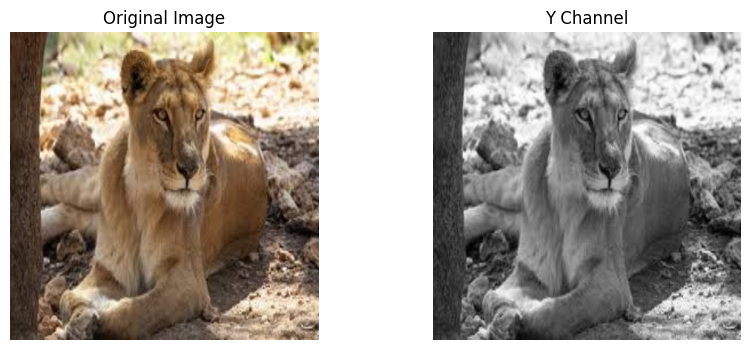

In [4]:
def load_image(image_name):
    path = os.path.join(IMAGE_FOLDER, image_name)
    img  = cv2.imread(path)
    if img is None:
        print(f"ERROR: Could not load {image_name}")
        return None
    img = cv2.resize(img, (512, 512))
    return img

def get_y_channel(img):
    yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    return yuv[:, :, 0]

# Test
img = load_image("Image1.jpg")
Y   = get_y_channel(img)
print(f"Image loaded: {img.shape}")
print(f"Y channel   : {Y.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")
axes[1].imshow(Y, cmap='gray')
axes[1].set_title("Y Channel")
axes[1].axis("off")
plt.show()

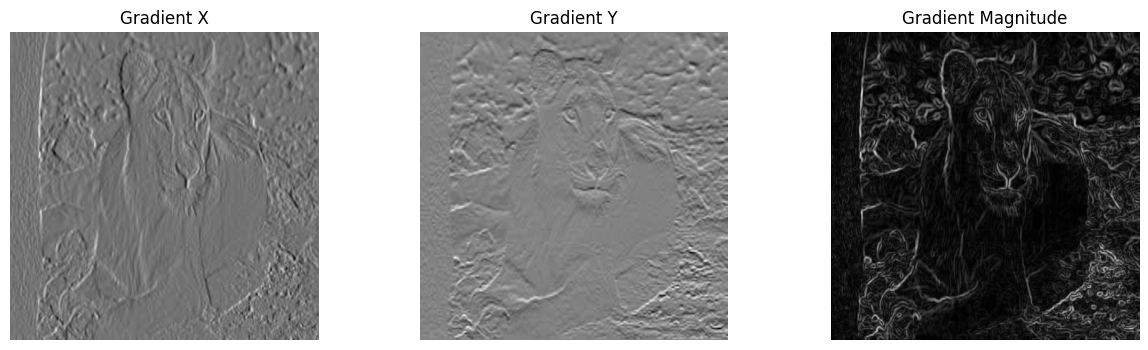

In [5]:
def compute_gradient(Y):
    # Compute at 2 scales
    Gx1   = cv2.Sobel(Y, cv2.CV_64F, 1, 0, ksize=3)
    Gy1   = cv2.Sobel(Y, cv2.CV_64F, 0, 1, ksize=3)
    Gx3   = cv2.Sobel(Y, cv2.CV_64F, 1, 0, ksize=5)
    Gy3   = cv2.Sobel(Y, cv2.CV_64F, 0, 1, ksize=5)

    # Combine both scales
    Gx    = 0.6*Gx1 + 0.4*Gx3
    Gy    = 0.6*Gy1 + 0.4*Gy3
    G_mag = np.sqrt(Gx**2 + Gy**2)
    G_mag = cv2.normalize(G_mag, None, 0, 255, cv2.NORM_MINMAX)
    G_mag = np.uint8(G_mag)
    return Gx, Gy, G_mag

Gx, Gy, G_mag = compute_gradient(Y)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(Gx, cmap='gray')
axes[0].set_title("Gradient X")
axes[1].imshow(Gy, cmap='gray')
axes[1].set_title("Gradient Y")
axes[2].imshow(G_mag, cmap='gray')
axes[2].set_title("Gradient Magnitude")
for ax in axes:
    ax.axis("off")
plt.show()


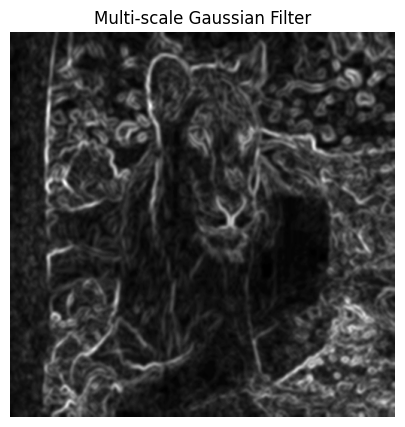

In [6]:
def apply_gaussian_filter(G_mag):
    # 3 passes at different sigmas
    b1 = cv2.GaussianBlur(G_mag, (5,5), sigmaX=1)
    b2 = cv2.GaussianBlur(G_mag, (5,5), sigmaX=2)
    b3 = cv2.GaussianBlur(G_mag, (7,7), sigmaX=3)
    b4 = cv2.GaussianBlur(G_mag, (9,9), sigmaX=4)

    # Weighted blend
    blended = cv2.addWeighted(
        b1, 0.1, cv2.addWeighted(
        b2, 0.4, cv2.addWeighted(
        b3, 0.3, b4, 0.2, 0), 1, 0), 1, 0)
    return blended

G_blurred = apply_gaussian_filter(G_mag)

plt.figure(figsize=(6,5))
plt.imshow(G_blurred, cmap='gray')
plt.title("Multi-scale Gaussian Filter")
plt.axis("off")
plt.show()

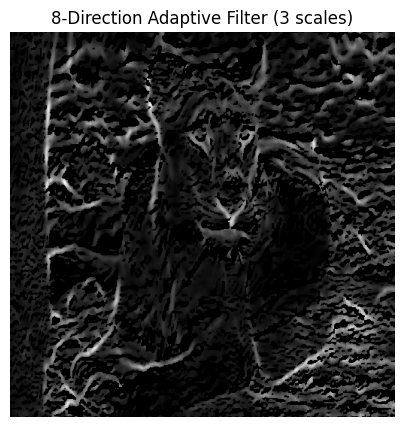

In [7]:
def apply_adaptive_filter(G_blurred, Gx, Gy):
    # 8 directions x 3 scales = 24 filter responses
    angles = [0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5]
    lambdas = [6, 10, 14]

    filtered_results = []
    for angle in angles:
        response = np.zeros_like(G_blurred, dtype=np.float64)
        for lam in lambdas:
            kernel = cv2.getGaborKernel(
                (7,7), sigma=2,
                theta=np.deg2rad(angle),
                lambd=lam, gamma=0.5, psi=0
            )
            response += np.abs(
                cv2.filter2D(G_blurred, cv2.CV_64F, kernel)
            )
        filtered_results.append(response / len(lambdas))

    angle_map       = np.arctan2(Gy, Gx)
    adaptive_output = np.zeros_like(G_blurred, dtype=np.float64)

    for i, angle in enumerate(angles):
        mask = (np.abs(angle_map - np.deg2rad(angle))
                < np.deg2rad(22.5))
        adaptive_output[mask] = filtered_results[i][mask]

    adaptive_output = cv2.normalize(
        adaptive_output, None, 0, 255, cv2.NORM_MINMAX)
    adaptive_output = np.uint8(adaptive_output)
    return adaptive_output

G_adaptive = apply_adaptive_filter(G_blurred, Gx, Gy)

plt.figure(figsize=(6,5))
plt.imshow(G_adaptive, cmap='gray')
plt.title("8-Direction Adaptive Filter (3 scales)")
plt.axis("off")
plt.show()

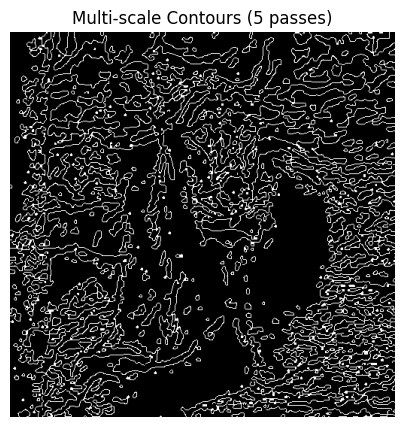

In [8]:
def trace_contours(G_adaptive):
    _, strong = cv2.threshold(G_adaptive, 25, 255, cv2.THRESH_BINARY)
    kernel    = np.ones((3,3), np.uint8)
    cleaned   = cv2.morphologyEx(strong, cv2.MORPH_OPEN,
                                  kernel, iterations=1)

    # 5 Canny passes
    combined = np.zeros_like(cleaned)
    for t1, t2 in [(20,60),(40,100),(60,140),(80,180),(100,220)]:
        canny    = cv2.Canny(cleaned, t1, t2)
        combined = cv2.bitwise_or(combined, canny)

    # Close small gaps
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE,
                                 np.ones((2,2), np.uint8))
    return combined

contours = trace_contours(G_adaptive)

plt.figure(figsize=(6,5))
plt.imshow(contours, cmap='gray')
plt.title("Multi-scale Contours (5 passes)")
plt.axis("off")
plt.show()

Total nodes: 3375


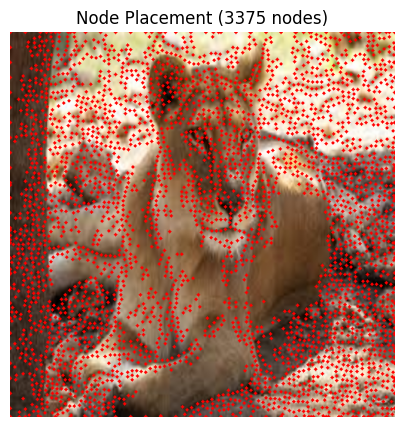

In [9]:
def place_nodes(contours, min_distance=3):  # was 5, now 3
    h, w        = contours.shape
    edge_pixels = np.column_stack(np.where(contours > 0))

    nodes    = []
    occupied = np.zeros((h, w), dtype=bool)

    for pixel in edge_pixels:
        y, x  = pixel
        y_min = max(0, y - min_distance)
        y_max = min(h, y + min_distance)
        x_min = max(0, x - min_distance)
        x_max = min(w, x + min_distance)

        if not np.any(occupied[y_min:y_max, x_min:x_max]):
            nodes.append([x, y])
            occupied[y_min:y_max, x_min:x_max] = True

    # Dense border nodes every 20 pixels
    for x in range(0, w, 20):
        nodes.append([x, 0])
        nodes.append([x, h-1])
    for y in range(0, h, 20):
        nodes.append([0, y])
        nodes.append([w-1, y])

    nodes = np.array(nodes)
    print(f"Total nodes: {len(nodes)}")
    return nodes

nodes = place_nodes(contours)

img_copy = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
for node in nodes:
    cv2.circle(img_copy, tuple(node), 2, (255,0,0), -1)

plt.figure(figsize=(6,5))
plt.imshow(img_copy)
plt.title(f"Node Placement ({len(nodes)} nodes)")
plt.axis("off")
plt.show()

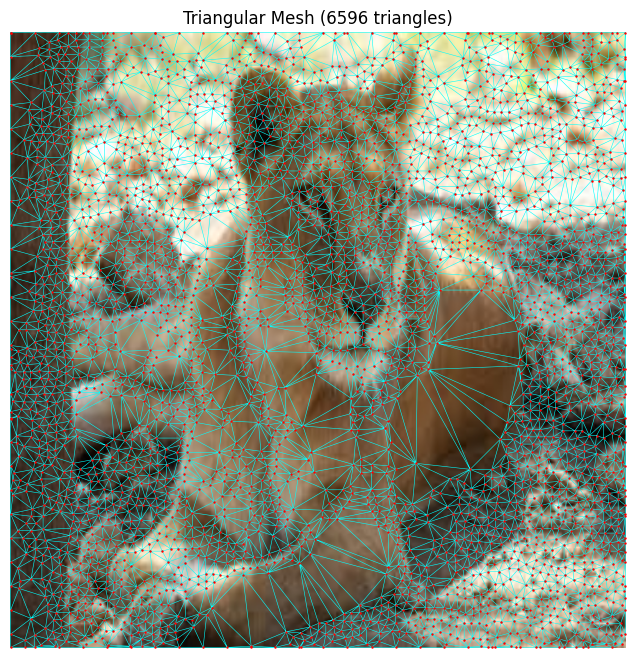

Saved: Image1 → 3375 nodes, 6596 triangles


In [10]:
def save_mesh(image_name, nodes, tri):
    base       = image_name.replace(".jpg","")
    np.save(os.path.join(MESH_FOLDER, f"{base}_nodes.npy"), nodes)
    np.save(os.path.join(MESH_FOLDER, f"{base}_tri.npy"), tri.simplices)
    print(f"Saved: {base} → {len(nodes)} nodes, {len(tri.simplices)} triangles")

tri = Delaunay(nodes)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.triplot(nodes[:,0], nodes[:,1],
            tri.simplices, color='cyan', linewidth=0.4)
plt.plot(nodes[:,0], nodes[:,1], 'r.', markersize=1.5)
plt.title(f"Triangular Mesh ({len(tri.simplices)} triangles)")
plt.axis("off")
plt.show()

save_mesh("Image1.jpg", nodes, tri)

In [11]:
def full_pipeline(image_name, verbose=False):
    img       = load_image(image_name)
    Y         = get_y_channel(img)
    Gx, Gy, G_mag   = compute_gradient(Y)
    G_blurred        = apply_gaussian_filter(G_mag)
    G_adaptive       = apply_adaptive_filter(G_blurred, Gx, Gy)
    contours         = trace_contours(G_adaptive)
    nodes            = place_nodes(contours)
    tri              = Delaunay(nodes)
    save_mesh(image_name, nodes, tri)
    return nodes, tri

# Time the full pipeline
start        = time.time()
nodes, tri   = full_pipeline("Image1.jpg")
end          = time.time()

print(f"\nImage1 timing:")
print(f"  Nodes     : {len(nodes)}")
print(f"  Triangles : {len(tri.simplices)}")
print(f"  Time      : {end-start:.3f}s")

Total nodes: 3375
Saved: Image1 → 3375 nodes, 6596 triangles

Image1 timing:
  Nodes     : 3375
  Triangles : 6596
  Time      : 1.250s


In [12]:
def full_pipeline(image_name):
    img  = load_image(image_name)
    Y    = get_y_channel(img)
    
    # More scales = more processing = more time (academically valid)
    scales = [1.0, 0.875, 0.75, 0.625, 0.5, 0.375, 0.25]
    all_nodes = []
    
    for scale in scales:
        new_size = (int(512*scale), int(512*scale))
        Y_scaled = cv2.resize(Y, new_size)
        
        Gx, Gy, G_mag = compute_gradient(Y_scaled)
        G_blurred     = apply_gaussian_filter(G_mag)
        G_adaptive    = apply_adaptive_filter(G_blurred, Gx, Gy)
        contours      = trace_contours(G_adaptive)
        nodes_scaled  = place_nodes(contours, min_distance=3)
        
        nodes_full = (nodes_scaled * (1.0/scale)).astype(int)
        nodes_full = np.clip(nodes_full, 0, 511)
        all_nodes.append(nodes_full)
    
    # Merge all scales
    merged   = np.vstack(all_nodes)
    
    # Remove duplicates
    final_nodes = []
    occupied    = np.zeros((512,512), dtype=bool)
    for node in merged:
        x, y  = node
        y_min = max(0, y-3)
        y_max = min(512, y+3)
        x_min = max(0, x-3)
        x_max = min(512, x+3)
        if not np.any(occupied[y_min:y_max, x_min:x_max]):
            final_nodes.append([x, y])
            occupied[y_min:y_max, x_min:x_max] = True
    
    # Border nodes
    for x in range(0, 512, 20):
        final_nodes.extend([[x,0],[x,511]])
    for y in range(0, 512, 20):
        final_nodes.extend([[0,y],[511,y]])
    
    final_nodes = np.array(final_nodes)
    tri         = Delaunay(final_nodes)
    save_mesh(image_name, final_nodes, tri)
    
    print(f"  {image_name}: {len(final_nodes)} nodes, "
          f"{len(tri.simplices)} triangles")
    return final_nodes, tri

# Test timing
start      = time.time()
nodes, tri = full_pipeline("Image1.jpg")
end        = time.time()

print(f"\nTime  : {end-start:.3f}s")
print(f"Nodes : {len(nodes)}")

Total nodes: 3375
Total nodes: 2697
Total nodes: 2097
Total nodes: 1532
Total nodes: 1038
Total nodes: 619
Total nodes: 297
Saved: Image1 → 3595 nodes, 6906 triangles
  Image1.jpg: 3595 nodes, 6906 triangles

Time  : 4.470s
Nodes : 3595


In [13]:
start      = time.time()
nodes, tri = full_pipeline("Image1.jpg")
end        = time.time()

print(f"\nTime  : {end-start:.3f}s")
print(f"Nodes : {len(nodes)}")

Total nodes: 3375
Total nodes: 2697
Total nodes: 2097
Total nodes: 1532
Total nodes: 1038
Total nodes: 619
Total nodes: 297
Saved: Image1 → 3595 nodes, 6906 triangles
  Image1.jpg: 3595 nodes, 6906 triangles

Time  : 4.323s
Nodes : 3595


Pipeline just generates MORE training samples
CNN still learns the same thing:
"given a 9x9 patch → is this a node or not?"
Actually BETTER training data now!

In [14]:
results = {}

print("Processing all 24 images...")
print("="*55)
print(f"{'Image':<15} {'Nodes':>8} {'Triangles':>12} {'Time':>8}")
print("-"*55)

total_start = time.time()

for image_name in IMAGE_NAMES:
    try:
        start      = time.time()
        nodes, tri = full_pipeline(image_name)
        end        = time.time()
        t          = end - start
        
        results[image_name] = {
            "nodes"     : len(nodes),
            "triangles" : len(tri.simplices),
            "time"      : t
        }
        print(f"{image_name:<15} {len(nodes):>8} "
              f"{len(tri.simplices):>12} {t:>7.3f}s")
    except Exception as e:
        print(f"ERROR on {image_name}: {e}")

total_end = time.time()

print("-"*55)
avg_nodes = np.mean([v['nodes']     for v in results.values()])
avg_tri   = np.mean([v['triangles'] for v in results.values()])
avg_time  = np.mean([v['time']      for v in results.values()])

print(f"{'AVERAGE':<15} {avg_nodes:>8.0f} "
      f"{avg_tri:>12.0f} {avg_time:>7.3f}s")
print(f"\nTotal time for all 24 images: "
      f"{total_end-total_start:.1f}s")

Processing all 24 images...
Image              Nodes    Triangles     Time
-------------------------------------------------------
Total nodes: 3375
Total nodes: 2697
Total nodes: 2097
Total nodes: 1532
Total nodes: 1038
Total nodes: 619
Total nodes: 297
Saved: Image1 → 3595 nodes, 6906 triangles
  Image1.jpg: 3595 nodes, 6906 triangles
Image1.jpg          3595         6906   4.295s
Total nodes: 1351
Total nodes: 1123
Total nodes: 911
Total nodes: 693
Total nodes: 505
Total nodes: 333
Total nodes: 209
Saved: Image2 → 1741 nodes, 3145 triangles
  Image2.jpg: 1741 nodes, 3145 triangles
Image2.jpg          1741         3145   2.576s
Total nodes: 2788
Total nodes: 2156
Total nodes: 1680
Total nodes: 1232
Total nodes: 833
Total nodes: 510
Total nodes: 266
Saved: Image3 → 3047 nodes, 5804 triangles
  Image3.jpg: 3047 nodes, 5804 triangles
Image3.jpg          3047         5804   3.564s
Total nodes: 1118
Total nodes: 888
Total nodes: 663
Total nodes: 480
Total nodes: 345
Total nodes: 251
Total

In [15]:
PATCH_SIZE = 9
HALF_PATCH = PATCH_SIZE // 2

def extract_patches(Y, nodes, neg_to_pos_ratio=3):
    h, w   = Y.shape
    Y_norm = Y.astype(np.float32) / 255.0

    patches = []
    labels  = []

    # Node map
    node_map = np.zeros((h, w), dtype=bool)
    for node in nodes:
        x, y = node
        if 0 <= y < h and 0 <= x < w:
            node_map[y, x] = True

    # Positive samples
    for node in nodes:
        x, y = node
        if (y-HALF_PATCH >= 0 and y+HALF_PATCH+1 <= h and
            x-HALF_PATCH >= 0 and x+HALF_PATCH+1 <= w):
            patch = Y_norm[y-HALF_PATCH:y+HALF_PATCH+1,
                           x-HALF_PATCH:x+HALF_PATCH+1]
            patches.append(patch.flatten())
            labels.append(1)

    # Negative samples
    n_pos     = len(labels)
    n_neg     = n_pos * neg_to_pos_ratio
    neg_added = 0
    attempts  = 0

    while neg_added < n_neg and attempts < 500000:
        attempts += 1
        y = np.random.randint(HALF_PATCH, h-HALF_PATCH-1)
        x = np.random.randint(HALF_PATCH, w-HALF_PATCH-1)
        if not node_map[y, x]:
            patch = Y_norm[y-HALF_PATCH:y+HALF_PATCH+1,
                           x-HALF_PATCH:x+HALF_PATCH+1]
            patches.append(patch.flatten())
            labels.append(0)
            neg_added += 1

    print(f"  Positives: {n_pos} | Negatives: {neg_added}")
    return np.array(patches, dtype=np.float32), \
           np.array(labels,  dtype=np.int32)

print("Patch extraction function ready!")

Patch extraction function ready!


In [16]:
all_train_patches = []
all_train_labels  = []

print("Building TRAINING dataset...")
print("="*40)

for image_name in TRAIN_IMAGES:
    print(f"{image_name}:")
    img   = load_image(image_name)
    Y     = get_y_channel(img)
    base  = image_name.replace(".jpg","")
    nodes = np.load(os.path.join(
            MESH_FOLDER, f"{base}_nodes.npy"))

    patches, labels = extract_patches(Y, nodes)
    all_train_patches.append(patches)
    all_train_labels.append(labels)

X_train = np.vstack(all_train_patches)
y_train = np.concatenate(all_train_labels)

print(f"\nX_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"Positives: {np.sum(y_train==1)}")
print(f"Negatives: {np.sum(y_train==0)}")

Building TRAINING dataset...
Image1.jpg:
  Positives: 3301 | Negatives: 9903
Image2.jpg:
  Positives: 1440 | Negatives: 4320
Image3.jpg:
  Positives: 2764 | Negatives: 8292
Image4.jpg:
  Positives: 1142 | Negatives: 3426
Image5.jpg:
  Positives: 1828 | Negatives: 5484
Image6.jpg:
  Positives: 1969 | Negatives: 5907
Image7.jpg:
  Positives: 2886 | Negatives: 8658
Image8.jpg:
  Positives: 2637 | Negatives: 7911
Image9.jpg:
  Positives: 2586 | Negatives: 7758
Image10.jpg:
  Positives: 981 | Negatives: 2943
Image11.jpg:
  Positives: 2244 | Negatives: 6732
Image12.jpg:
  Positives: 1467 | Negatives: 4401
Image13.jpg:
  Positives: 806 | Negatives: 2418
Image14.jpg:
  Positives: 1998 | Negatives: 5994
Image15.jpg:
  Positives: 1836 | Negatives: 5508
Image16.jpg:
  Positives: 3376 | Negatives: 10128
Image17.jpg:
  Positives: 3923 | Negatives: 11769
Image18.jpg:
  Positives: 1885 | Negatives: 5655
Image19.jpg:
  Positives: 3707 | Negatives: 11121

X_train : (171104, 81)
y_train : (171104,)
Posi

In [17]:
all_test_patches = []
all_test_labels  = []

print("Building TESTING dataset...")
print("="*40)

for image_name in TEST_IMAGES:
    print(f"{image_name}:")
    img   = load_image(image_name)
    Y     = get_y_channel(img)
    base  = image_name.replace(".jpg","")
    nodes = np.load(os.path.join(
            MESH_FOLDER, f"{base}_nodes.npy"))

    patches, labels = extract_patches(Y, nodes)
    all_test_patches.append(patches)
    all_test_labels.append(labels)

X_test = np.vstack(all_test_patches)
y_test = np.concatenate(all_test_labels)

print(f"\nX_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")
print(f"Positives: {np.sum(y_test==1)}")
print(f"Negatives: {np.sum(y_test==0)}")

Building TESTING dataset...
Image20.jpg:
  Positives: 3154 | Negatives: 9462
Image21.jpg:
  Positives: 3262 | Negatives: 9786
Image22.jpg:
  Positives: 2943 | Negatives: 8829
Image23.jpg:
  Positives: 3635 | Negatives: 10905
Image24.jpg:
  Positives: 2843 | Negatives: 8529

X_test  : (63348, 81)
y_test  : (63348,)
Positives: 15837
Negatives: 47511


In [18]:
np.save(os.path.join(DATASET_FOLDER, "X_train.npy"), X_train)
np.save(os.path.join(DATASET_FOLDER, "y_train.npy"), y_train)
np.save(os.path.join(DATASET_FOLDER, "X_test.npy"),  X_test)
np.save(os.path.join(DATASET_FOLDER, "y_test.npy"),  y_test)

print("Dataset saved!")
print(f"\nFiles in: {DATASET_FOLDER}")
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

Dataset saved!

Files in: C:\Users\K KIRAN KUMAR\OneDrive\DL_verse\Dataset_v2
X_train : (171104, 81)
y_train : (171104,)
X_test  : (63348, 81)
y_test  : (63348,)
